# Evaluation of Low-Pass Filter RNN
## Model loading

In [14]:
from model import LowpassRNN
import torch
from pathlib import Path
import numpy as np
import os

In [15]:
hidden_size = 64
num_layers = 2
buffer_size = 96
sample_rate = 48000
checkpoint_folder = "checkpoints-8"
dataset_folder = "dataset-1"
dataset_size = 599

In [16]:
state = torch.load(
    "lowpass_rnn.pt",
    map_location=torch.device("cpu")
)
filter_rnn = LowpassRNN(hidden_size, num_layers)
filter_rnn.load_state_dict(state)
filter_rnn.eval()

LowpassRNN(
  (gru): GRU(2, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

### Test model with known data

In [34]:
from create_dataset_v2 import normalize_freq
def run_inference(
    model: LowpassRNN,
    input: np.ndarray,
    fc_norm: float,
    buffer_size: int,
    sample_rate: int,
) -> np.ndarray:
    """
    Args:
        model:       trained LowpassRNN
        input:       raw audio signal of length N, where N is a multiple of buffer_size
        fc_norm:     normalized cutoff frequency (2 * cutoff_freq / sample_rate)
        buffer_size: must match the buffer_size used during training
        sample_rate: must match the sample_rate used during training
    Returns:
        filtered signal of length N
    """
    model.eval()

    n_buffers = len(input) // buffer_size
    output_buffers = []
    hidden = None

    with torch.no_grad():
        for i in range(n_buffers):
            buffer = input[i * buffer_size : (i + 1) * buffer_size]
            x = torch.from_numpy(buffer).float()  # (buffer_size,)
            fc_channel = torch.full((buffer_size,), fc_norm)
            x = torch.stack([x, fc_channel], dim=-1).unsqueeze(0)  # (1, buffer_size, 2)
            if hidden != None:
                print(hidden[0, 0, :8])
            output, hidden = model(x, hidden)

            # .cpu() handles both CUDA and CPU tensors safely before .numpy()
            output_buffers.append(output.squeeze().cpu().numpy())  # (buffer_size,)

    return np.concatenate(output_buffers)  # (N,)

In [66]:
from random import randint

data_idx = randint(0, dataset_size)
x = np.load(os.path.join(dataset_folder, "inputs/input-{}.npy".format(data_idx)))
y = np.load(os.path.join(dataset_folder, "expected/expected-{}.npy".format(data_idx)))
print("Sample {}".format(data_idx))

y_pred = run_inference(
    filter_rnn, x[:-1], fc_norm=x[-1], buffer_size=buffer_size, sample_rate=sample_rate
)

Sample 102


(102401,)
(102400,)
(102336,)


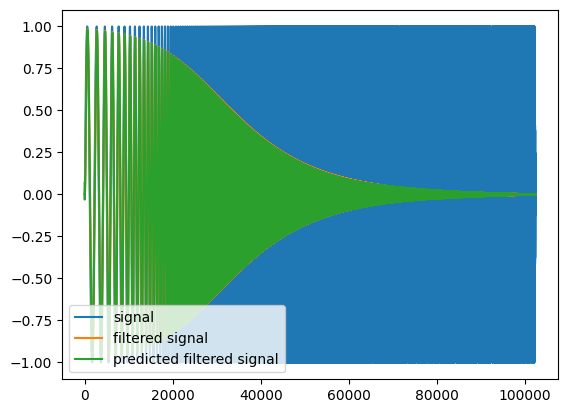

In [67]:
import matplotlib.pyplot as plt

print(x.shape)
print(y.shape)
print(y_pred.shape)
t = np.arange(len(y))
plt.figure()
plt.plot(t, x[:-1], label="signal")
plt.plot(t, y, label="filtered signal")
plt.plot(t[:min(len(t), len(y_pred))], y_pred, label="predicted filtered signal")
plt.legend(loc="lower left")
plt.show()

### Test model with unknown data

In [68]:
from create_dataset import lowpass_filter
import colorednoise as cn

cutoff_freq = 250 # Hz
length = 2 # seconds

buffer_amount_in_length = (length * sample_rate) // buffer_size
N = buffer_amount_in_length * buffer_size
beta = 0  # the exponent: 0=white noite; 1=pink noise;  2=red noise (also "brownian noise")

brown_noise = cn.powerlaw_psd_gaussian(beta, N)
filtered_noise = lowpass_filter(brown_noise, cutoff_freq, sample_rate)

fc_norm = normalize_freq(cutoff_freq, sample_rate)

pred = run_inference(filter_rnn, brown_noise, fc_norm, buffer_size, sample_rate)


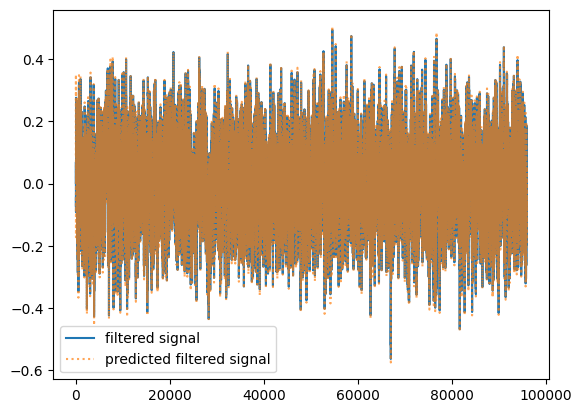

In [69]:
t = np.arange(len(pred))
plt.figure()
# plt.plot(t, brown_noise, label="signal")
plt.plot(t, filtered_noise, label="filtered signal")
plt.plot(t, pred, label="predicted filtered signal", linestyle="dotted", alpha=.7)
plt.legend(loc="lower left")
plt.show()

In [71]:
from create_dataset import generate_log_sweep, cut_to_nearest_multiple

cutoff_freq = 50  # Hz
length = 2  # seconds

sweeps, fsweeps = generate_log_sweep(sample_rate, 20, 7500, 1.1, cutoff_freq)

print(len(sweeps))

fc_norm = normalize_freq(cutoff_freq, sample_rate)

sweeps = cut_to_nearest_multiple(sweeps, buffer_size)
fsweeps = cut_to_nearest_multiple(fsweeps, buffer_size)
pred_fsweeps = run_inference(filter_rnn, sweeps, fc_norm, buffer_size, sample_rate)

t = np.arange(len(pred_fsweeps))

26308


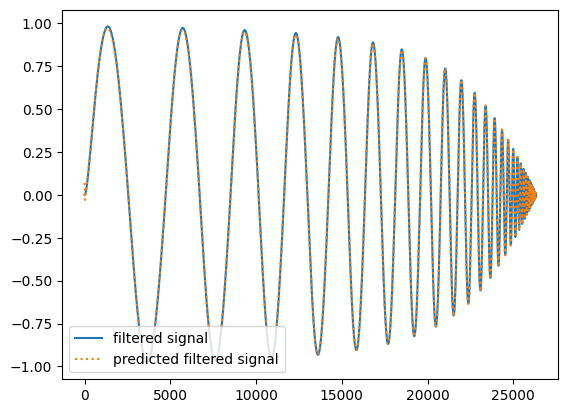

In [73]:
plt.figure()
# plt.plot(t, sweeps, label="signal")
plt.plot(t, fsweeps, label="filtered signal")
plt.plot(t, pred_fsweeps, label="predicted filtered signal", linestyle="dotted")
plt.legend(loc="lower left")
plt.show()

Interestingly enough, the RNN model seems to have a steeper slope than the filter it learned from for lower cutoff frequencies.

In [80]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_bode_steadystate(
    model: LowpassRNN,
    cutoff_freq: float,
    buffer_size: int,
    sample_rate: int,
    n_freqs: int = 100,
    n_warmup_buffers: int = 32,  # buffers to let hidden state settle, discarded
    n_measure_buffers: int = 16,  # buffers to average amplitude over
):
    model.eval()
    fc_norm = normalize_freq(cutoff_freq, sample_rate)

    freqs = np.geomspace(20, 20000, n_freqs)  # log-spaced, 20Hz to Nyquist
    magnitudes_db = []

    with torch.no_grad():
        for freq in freqs:
            # Build a long sine wave: warmup + measurement
            n_total = (n_warmup_buffers + n_measure_buffers) * buffer_size
            t = np.arange(n_total) / sample_rate
            sine = np.sin(2 * np.pi * freq * t).astype(np.float32)

            # Run inference buffer by buffer
            hidden = None
            output_buffers = []
            for i in range(n_warmup_buffers + n_measure_buffers):
                buffer = sine[i * buffer_size : (i + 1) * buffer_size]
                x = torch.from_numpy(buffer).float()
                fc_channel = torch.full((buffer_size,), fc_norm)
                x = torch.stack([x, fc_channel], dim=-1).unsqueeze(
                    0
                )  # (1, buffer_size, 2)
                output, hidden = model(x, hidden)
                hidden = hidden.detach()
                if i >= n_warmup_buffers:  # only keep post-warmup output
                    output_buffers.append(output.squeeze().cpu().numpy())

            # Measure amplitude as RMS of the steady-state output
            steady_state = np.concatenate(output_buffers)
            rms_out = np.sqrt(np.mean(steady_state**2))
            rms_in = np.sqrt(
                np.mean(sine[n_warmup_buffers * buffer_size :] ** 2)
            )  # always 1/√2 for sine, but explicit is safer
            gain = rms_out / (rms_in + 1e-8)
            magnitudes_db.append(20 * np.log10(gain + 1e-8))

    # Reference Butterworth
    from scipy.signal import freqz, butter

    b, a = butter(1, cutoff_freq / (20000), btype="low", analog=False)
    w, h = freqz(b, a, worN=n_freqs, fs=sample_rate)
    reference_db = 20 * np.log10(np.abs(h) + 1e-8)

    plt.figure(figsize=(10, 5))
    plt.semilogx(freqs, magnitudes_db, label="RNN filter")
    plt.semilogx(w, reference_db, "--", label="Reference Butterworth")
    plt.axvline(cutoff_freq, color="r", linestyle=":", label=f"fc = {cutoff_freq} Hz")
    plt.axhline(-3, color="gray", linestyle=":", label="-3 dB")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"Bode Magnitude Plot (steady-state) — fc = {cutoff_freq} Hz")
    plt.legend()
    plt.grid(True, which="both")
    plt.tight_layout()
    plt.show()

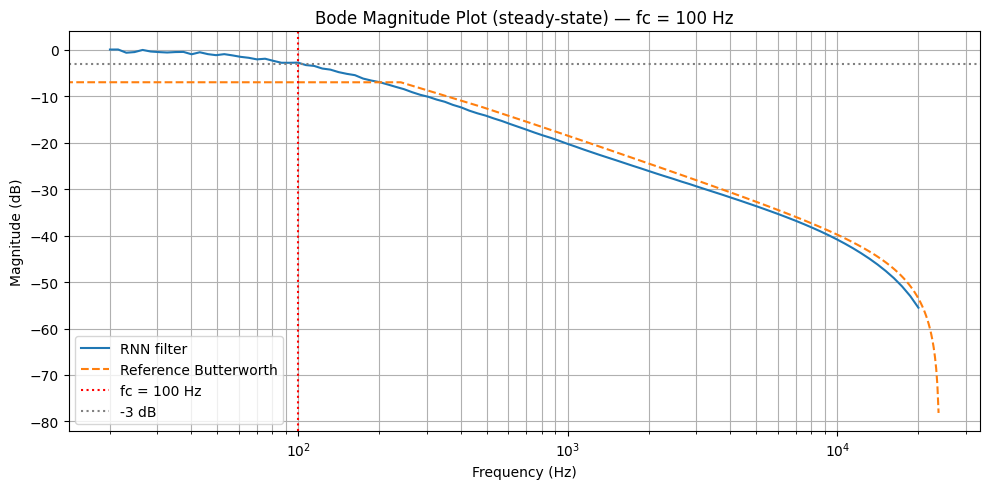

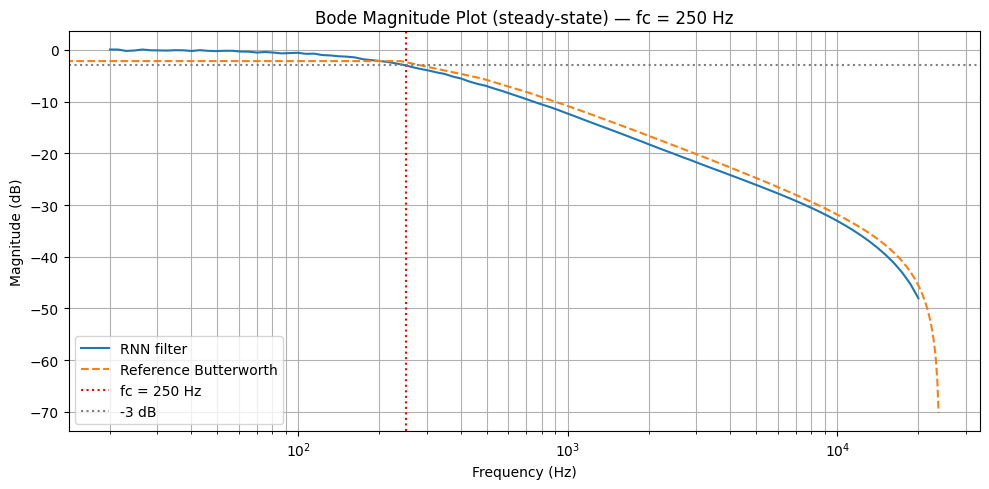

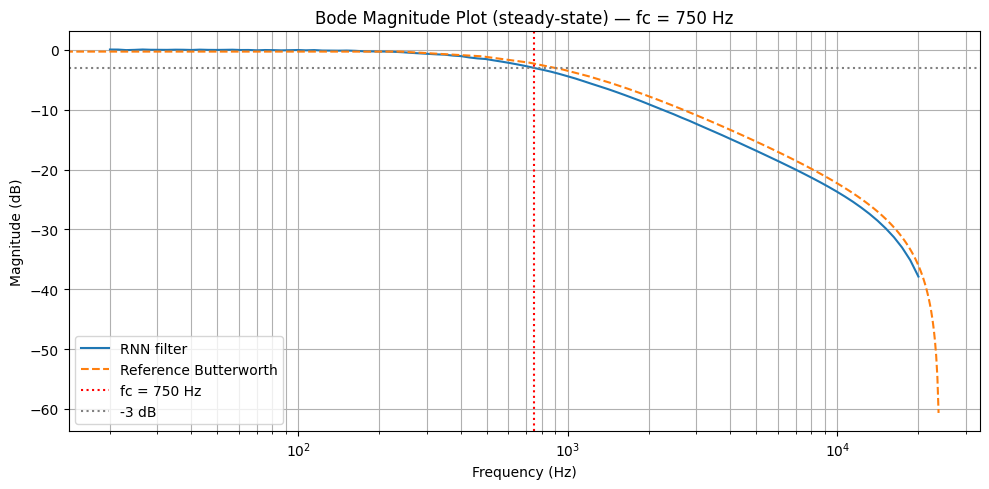

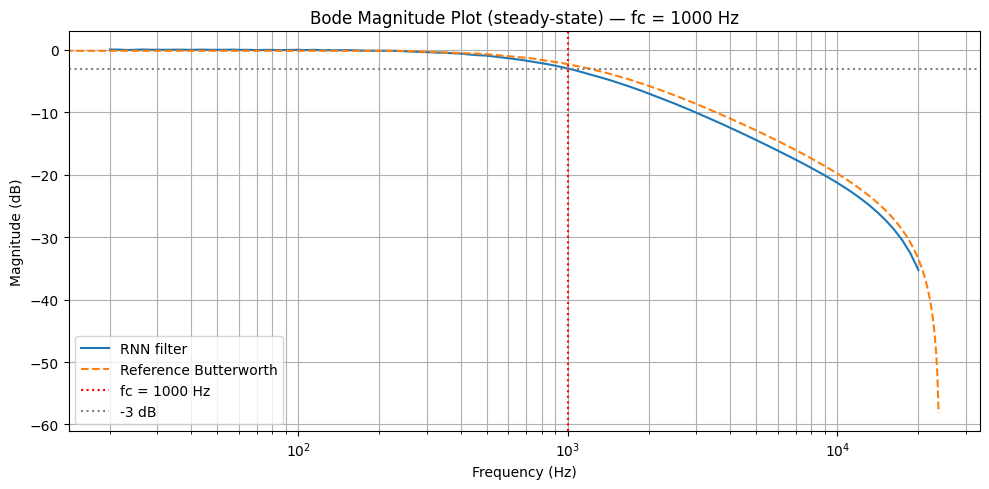

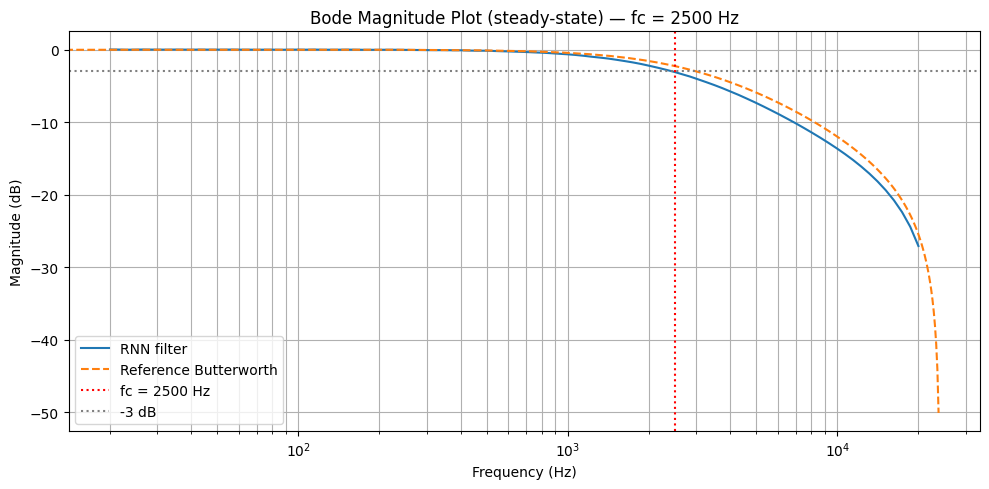

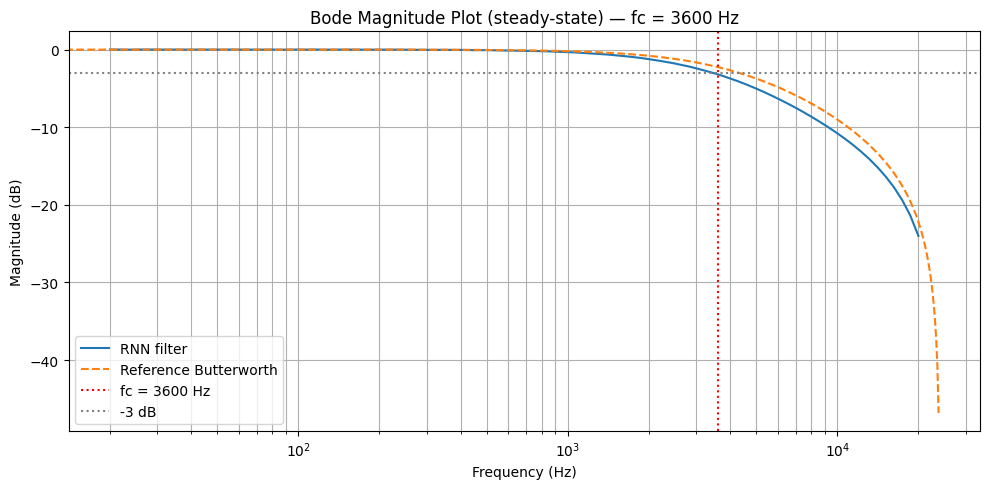

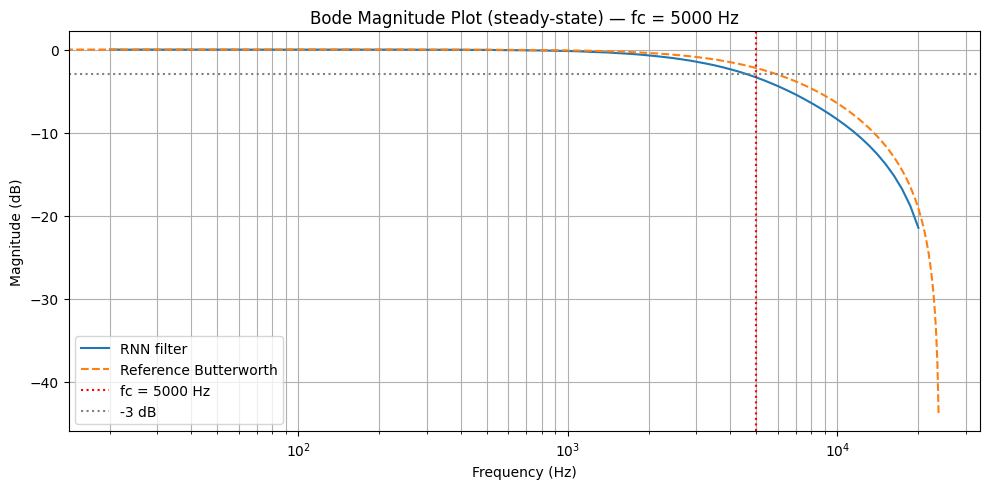

In [81]:
for fc in [100, 250, 750, 1000, 2500, 3600, 5000]:
    plot_bode_steadystate(filter_rnn, fc, buffer_size, sample_rate)

## ONNX Runtime inference test

In [39]:
import onnx

model = onnx.load("lowpass_rnn2.onnx")
for inp in model.graph.input:
    print(inp.name, inp.type.tensor_type.shape)

x dim {
  dim_value: 1
}
dim {
  dim_value: 96
}
dim {
  dim_value: 2
}

hidden_in dim {
  dim_value: 2
}
dim {
  dim_value: 1
}
dim {
  dim_value: 64
}



tensor([ 0.1177, -0.1435, -0.1774,  0.2378, -0.0346, -0.0289, -0.2821, -0.2692])
tensor([ 0.1399, -0.0782, -0.1776,  0.2105,  0.0103, -0.0639, -0.2522, -0.2973])
tensor([ 0.1710,  0.0108, -0.1727,  0.1715,  0.0693, -0.1114, -0.2039, -0.3280])
tensor([ 0.1837,  0.0453, -0.1700,  0.1558,  0.0920, -0.1295, -0.1838, -0.3388])
tensor([ 0.1785,  0.0285, -0.1686,  0.1642,  0.0798, -0.1232, -0.1922, -0.3331])
tensor([ 0.1468, -0.0660, -0.1698,  0.2076,  0.0155, -0.0782, -0.2421, -0.3018])
tensor([ 0.0959, -0.2271, -0.1754,  0.2756, -0.0922,  0.0110, -0.3207, -0.2406])
tensor([ 0.0588, -0.3553, -0.1837,  0.3245, -0.1778,  0.1004, -0.3759, -0.1777])
tensor([ 0.0696, -0.3040, -0.1893,  0.3003, -0.1401,  0.0768, -0.3574, -0.1977])
tensor([ 0.1471, -0.0489, -0.1823,  0.1957,  0.0322, -0.0724, -0.2393, -0.3068])
tensor([ 0.1733,  0.0081, -0.1656,  0.1750,  0.0643, -0.1168, -0.2013, -0.3262])
tensor([ 0.0671, -0.3309, -0.1755,  0.3182, -0.1635,  0.0730, -0.3641, -0.1947])
tensor([ 0.1134, -0.1402, -0

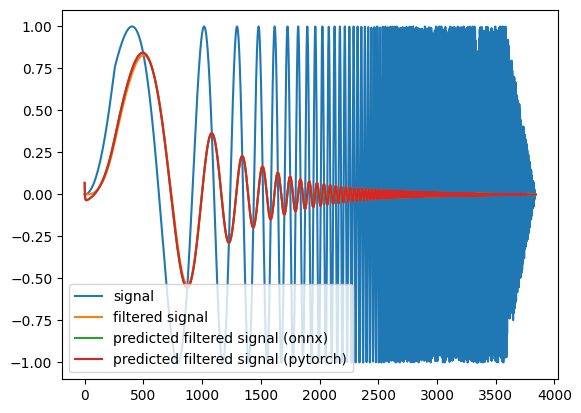

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import onnxruntime as ort
import numpy as np

hidden_size = 64
num_layers = 2
buffer_size = 96
sample_rate = 48000

state = torch.load("lowpass_rnn.pt", map_location=torch.device("cpu"))
filter_rnn = LowpassRNN(hidden_size, num_layers)
filter_rnn.load_state_dict(state)
filter_rnn.eval()

input_idx = 9
dataset_idx = 10
x = np.load("dataset-{}/inputs/input-{}.npy".format(dataset_idx, input_idx))
y = np.load("dataset-{}/expected/expected-{}.npy".format(dataset_idx, input_idx))

y_pred = np.load("onnx_inference_test/output-{}.npy".format(input_idx))
y_pred_py = run_inference(
    filter_rnn, x[:-1], fc_norm=x[-1], buffer_size=96, sample_rate=sample_rate
)

print(x.shape)
print(y.shape)
print(y_pred.shape)
t = np.arange(len(y))
m = min(len(t), len(y_pred))

plt.figure()
plt.plot(t, x[:m], label="signal")
plt.plot(t, y, label="filtered signal")
plt.plot(t[:m], y_pred[:m], label="predicted filtered signal (onnx)")
plt.plot(t[:m], y_pred_py[:m], label="predicted filtered signal (pytorch)")
plt.legend(loc="lower left")
plt.show()